# Topological spline graph on synthetic point distributions

The reusable implementation lives in `topological_graph_embedding.visualization.workflows.synthetic`. The static view is split into a fast easy-example cell and a separate higher-resolution complex-example cell. Both use the same four-panel visualization: fitted graph, graph embedding, metro-map lines, and metro-map points.

In [1]:
from pathlib import Path
import sys

working_dir = Path.cwd().resolve()
notebooks_dir = working_dir / 'notebooks' if (working_dir / 'notebooks' / '__init__.py').exists() else working_dir
project_root = notebooks_dir.parent
if not (project_root / 'topological_graph_embedding').exists():
    raise RuntimeError('Start Jupyter from the repository root or its notebooks/ directory')
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(notebooks_dir))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from topological_graph_embedding.visualization.workflows.synthetic import (
    build_datasets,
    fit_datasets,
    _plot_summary,
)
from topological_graph_embedding.visualization.plots import plot_embedding_row

HYPERCUBE_DIM = 3
POLYGON_SIDES = 3
BINARY_TREE_DEPTH = 3
STAR_BRANCHES = 4
N_POINTS = 1000
NOISE = 0.045
N_CENTROIDS = 50
SPLINE_SMOOTHING = 0.005
MAX_CYCLES = 5
PERSISTENCE_THRESHOLD = 4.0
EASY_DATASET_NAMES = [
    'line', 'star', 'circle', 'figure-eight',
    'binary-tree', 'loop-branch',
]
COMPLEX_DATASET_NAMES = ['polygon-rays-circles', 'hypercube']

datasets = build_datasets(
    n=N_POINTS,
    noise=NOISE,
    hypercube_dim=HYPERCUBE_DIM,
    polygon_sides=POLYGON_SIDES,
    binary_tree_depth=BINARY_TREE_DEPTH,
    star_branches=STAR_BRANCHES,
)
figure_dir = project_root / 'notebooks' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)

def render_group(names, persistence_max_points, figure_name, summary_name, title):
    group = {name: datasets[name] for name in names}
    models, projections, summary = fit_datasets(
        group,
        n_centroids=N_CENTROIDS,
        persistence_max_points=persistence_max_points,
        persistence_threshold=PERSISTENCE_THRESHOLD,
        spline_smoothing=SPLINE_SMOOTHING,
        max_cycles=MAX_CYCLES,
    )
    fig, axes = plt.subplots(
        len(group), 4, figsize=(26, 4 * len(group)), squeeze=False,
    )
    reducers = {
        name: PCA(n_components=2, random_state=0).fit(points)
        if points.shape[1] > 2 else None
        for name, points in group.items()
    }
    for row, (name, points) in enumerate(group.items()):
        labels = np.zeros(len(points), dtype=int)
        display_title = name.replace('-', ' ').title()
        if reducers[name] is not None:
            display_title += ' (PCA view)'
        plot_embedding_row(
            axes=axes[row],
            points=points,
            labels=labels,
            model=models[name],
            result=projections[name],
            projected_title=display_title,
            graph_title=f'{name}: graph embedding',
            metro_lines_title=f'{name}: metro-map lines',
            metro_points_title=f'{name}: metro-map points',
            reducer=reducers[name],
            colors=None,
            jitter_seed=row,
            layout=None,
            show_metro_nodes=False,
            classification_metrics=None,
            route_metrics=None,
            metro_residual_width=0.02,
        )
    fig.suptitle(title, fontsize=16, y=0.995)
    fig.tight_layout()
    fig.savefig(figure_dir / figure_name, dpi=160, bbox_inches='tight')
    plt.show()
    _plot_summary(summary, figure_dir, filename=summary_name)
    return models, projections, summary


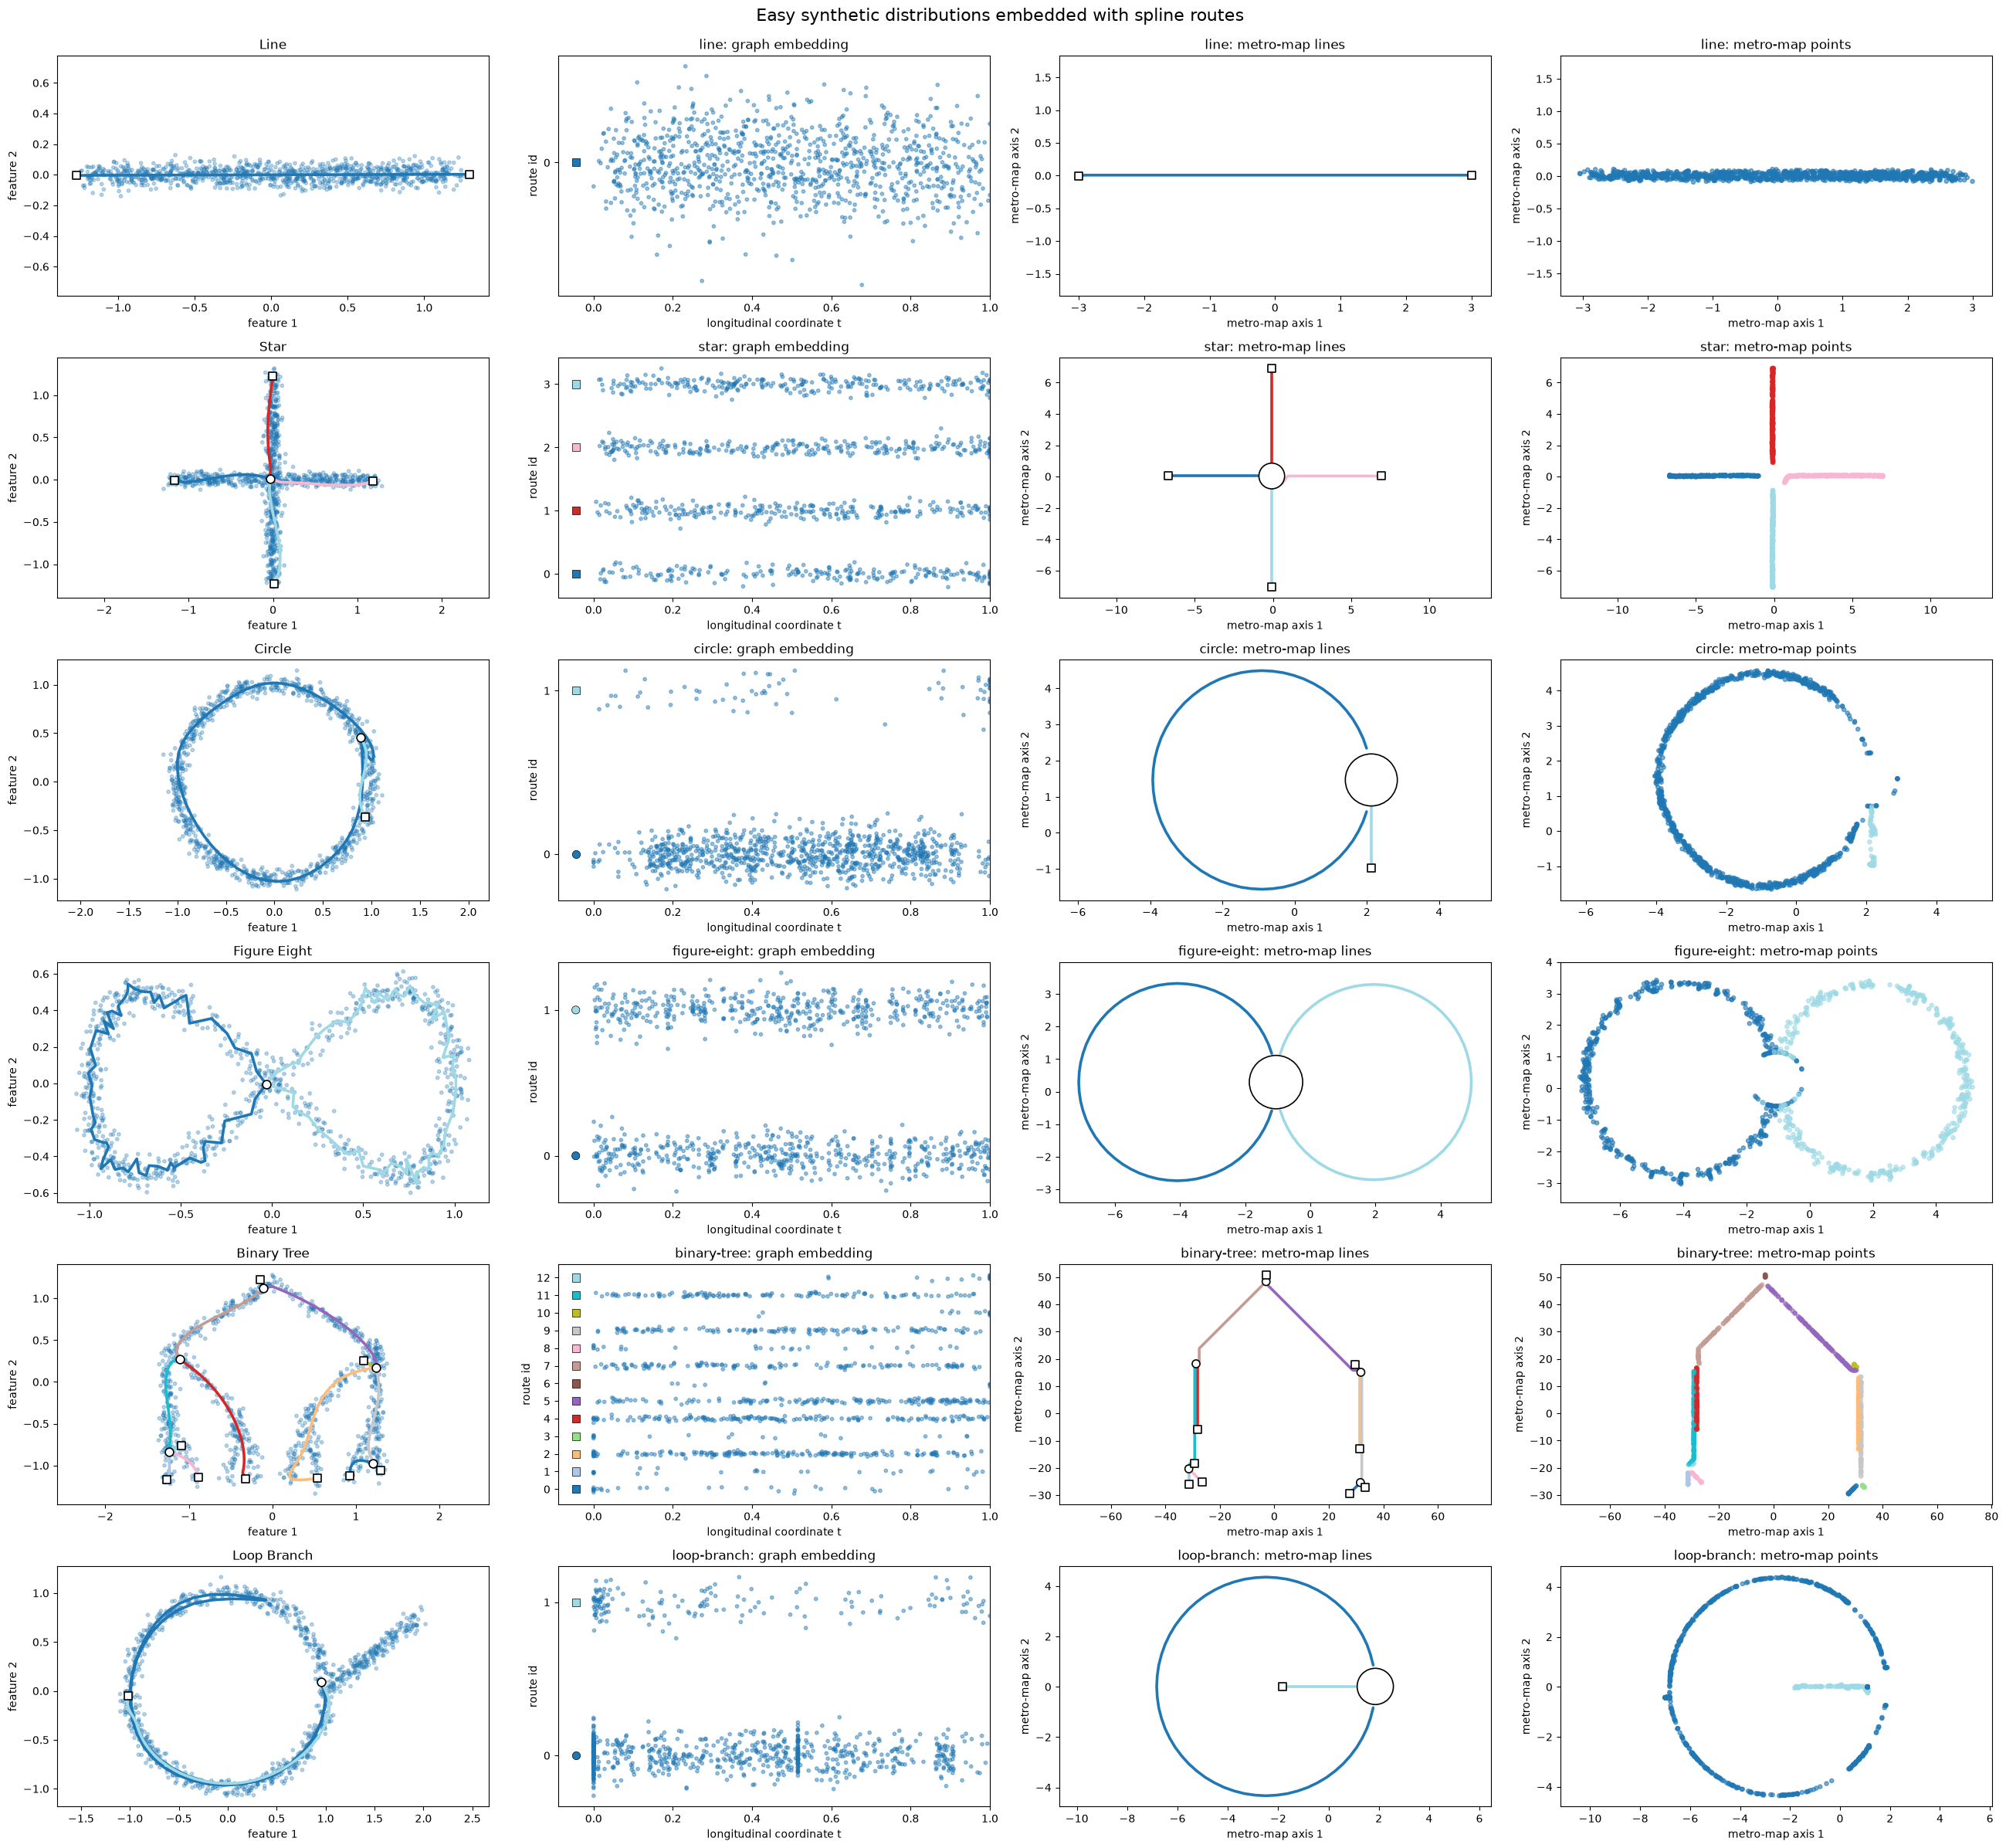

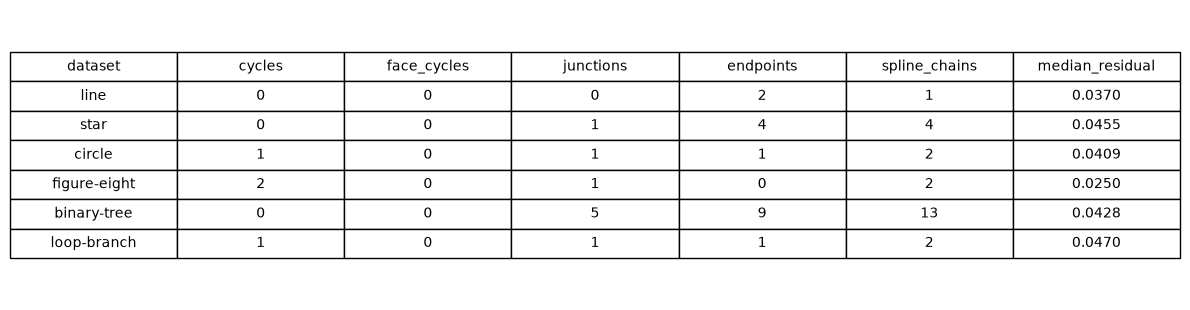

In [2]:
# Fast cell: stable low-complexity synthetic examples.
easy_models, easy_projections, easy_summary = render_group(
    EASY_DATASET_NAMES,
    persistence_max_points=60,
    figure_name='synthetic_easy.png',
    summary_name='synthetic_easy_summary.png',
    title='Easy synthetic distributions embedded with spline routes',
)

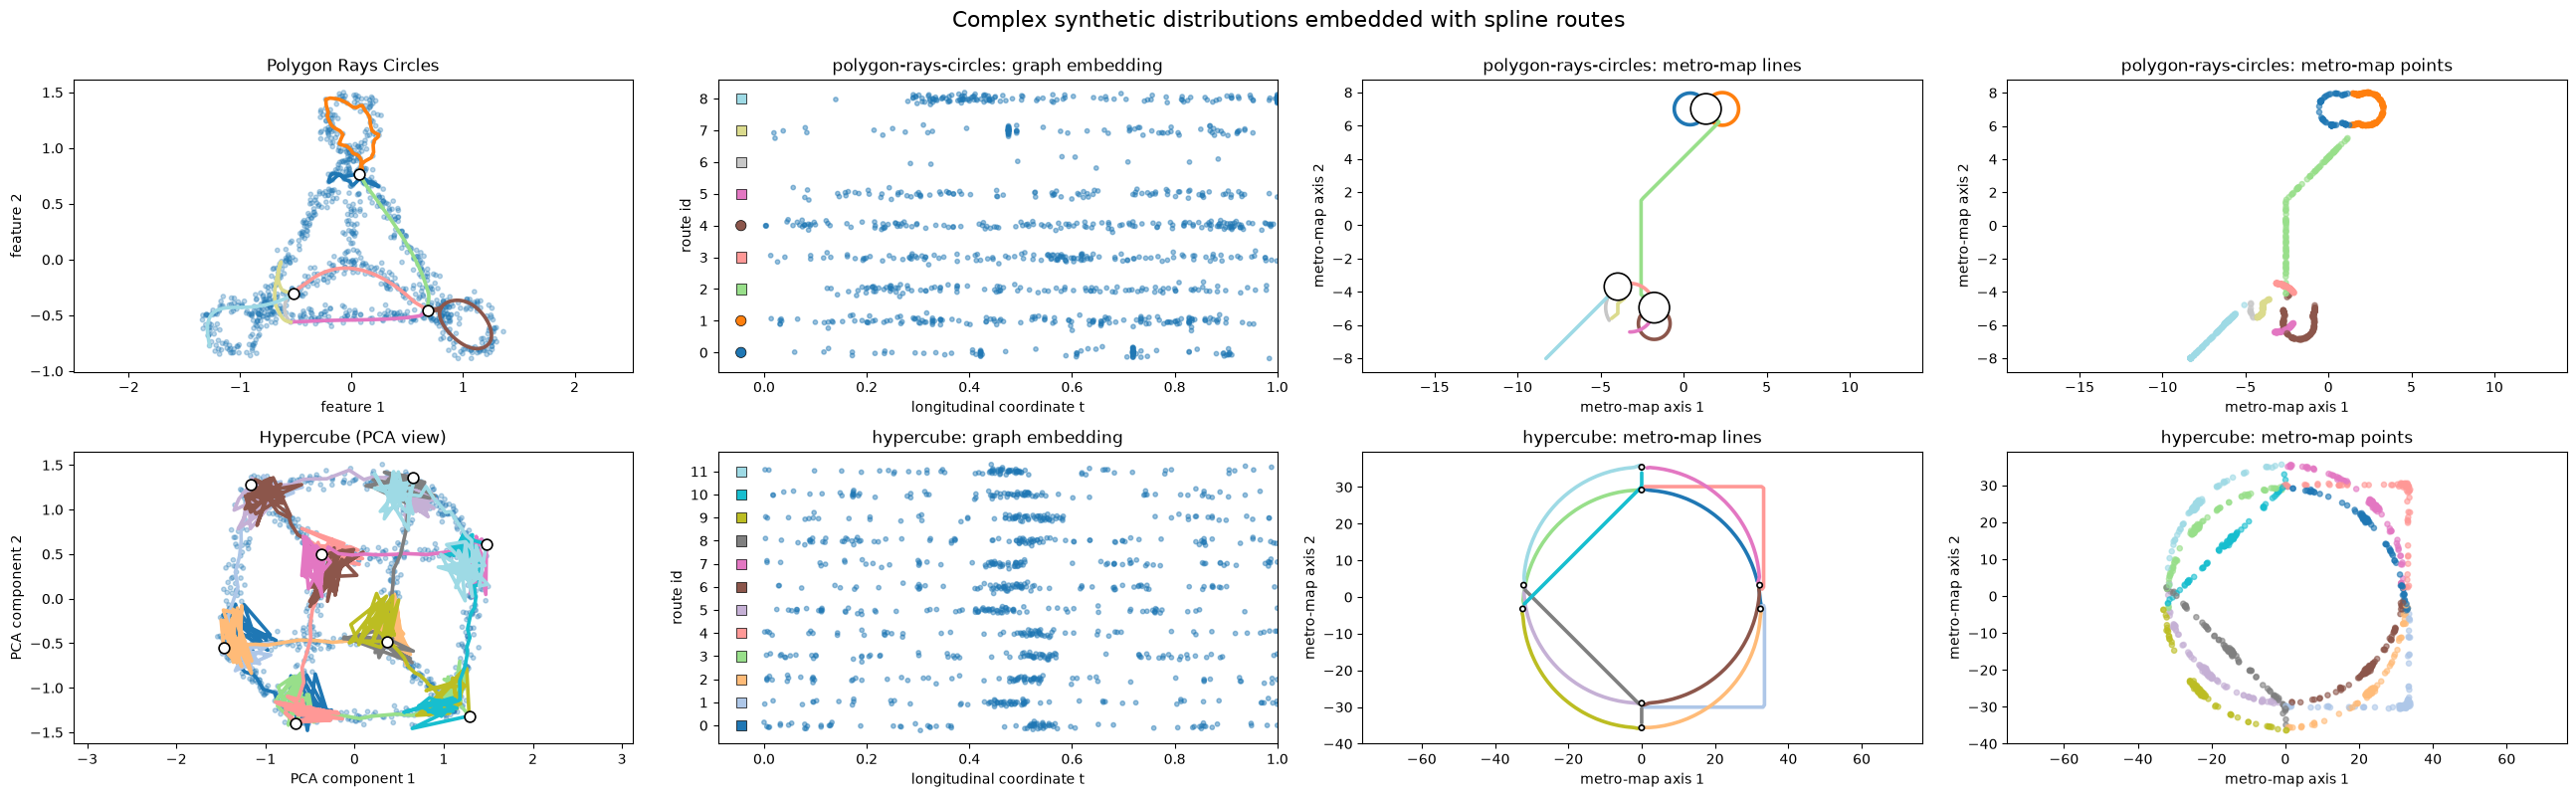

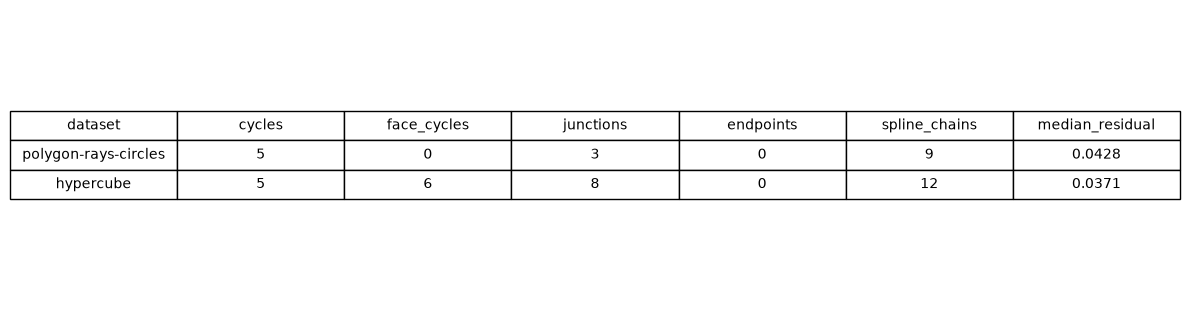

In [3]:
# Detailed cell: run this separately when the complex topology is needed.
complex_models, complex_projections, complex_summary = render_group(
    COMPLEX_DATASET_NAMES,
    persistence_max_points=300,
    figure_name='synthetic_complex.png',
    summary_name='synthetic_complex_summary.png',
    title='Complex synthetic distributions embedded with spline routes',
)

## Interactive parameter exploration

Select a dataset, adjust the fitting parameters, and press **Refit selected dataset**.

In [4]:
from topological_graph_embedding.visualization.workflows.synthetic import display_interactive_controls

display_interactive_controls(datasets)